<a href="https://colab.research.google.com/github/vasanthraodasandla/Tourism-Popularity-with-Reviews/blob/main/Copy_of_Copy_of_Paper1Code_with_Comments_version1_01102024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This cell mounts Google Drive to access files stored in it.
#from google.colab import drive https://www.gstatic.com/images/branding/product/2x/googleg_24dp.png
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# This cell installs the required Python libraries.
!pip install pandas scikit-learn transformers torch matplotlib seaborn



In [ ]:
# This cell extracts the dataset from a ZIP file stored on Google Drive.
!unzip /content/drive/MyDrive/Review_db.zip



Archive:  /content/drive/MyDrive/Review_db.zip
  inflating: Review_db.csv           


In [ ]:
#importing libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Read the dataset
dataset_path = '/content/drive/MyDrive/TourismPopularity_WithReviews/Review_db.csv'
df = pd.read_csv(dataset_path)

In [ ]:
df.Review='|'+df['City']+'|'+df['Place']+'|'+df['Review']+'|'+df['Rating'].astype(str)
df.to_csv('ReviewVerification.txt', columns=['Review'])

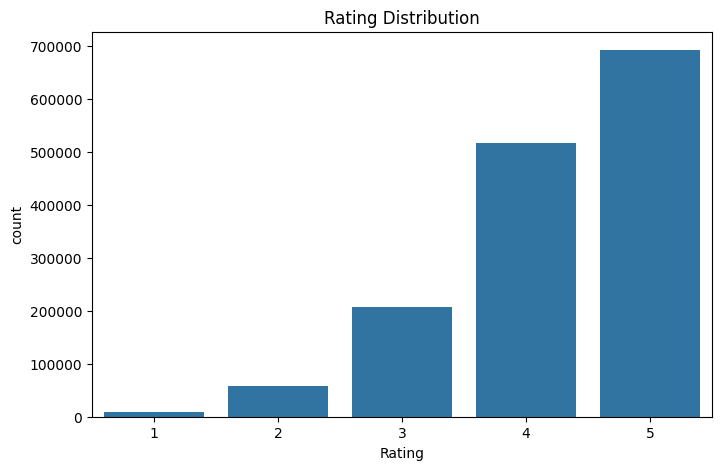

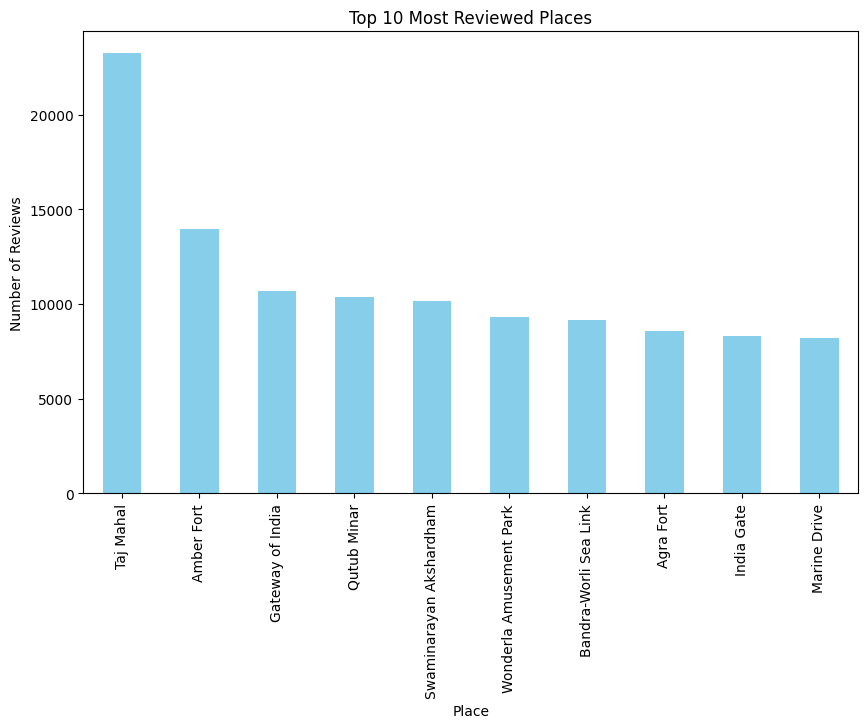

In [ ]:
# Step 2: Isolate the columns: city, place, review, and rating
df = df[['City', 'Place', 'Review', 'Rating']]

# Step 3: Look for missing values, remove rows with any missing data
df.dropna(inplace=True)

# Step 4: Perform EDA analysis
# Distribution of ratings
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Rating')
plt.title("Rating Distribution")
plt.show()

# Top 10 most reviewed places
top_places = df['Place'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_places.plot(kind='bar', color='skyblue')
plt.title("Top 10 Most Reviewed Places")
plt.xlabel("Place")
plt.ylabel("Number of Reviews")
plt.show()



In [ ]:
row,colum=df.shape
print(f"Number of rows: {row}")
print(f"Number of columns: {colum}")


Number of rows: 1482466
Number of columns: 4


In [ ]:
# Step 5: Build a popularity index system based on the review and rating
# df['Popularity'] = df['Rating'].apply(lambda x: 1 if x >= 4 else 0)
import pandas as pd

# Assuming df is your DataFrame with the 'Rating' column
# Step 1: Count the number of reviews with rating 2
rating_2_count = df[df['Rating'] == 2].shape[0]
print(f"Number of reviews with rating 2: {rating_2_count}")

# Step 2: Take equal samples of reviews from ratings 3, 4, and 5
# Sample size is based on the count of rating 2
rating_3_sample = df[df['Rating'] == 3].sample(n=rating_2_count, random_state=45)
rating_4_sample = df[df['Rating'] == 4].sample(n=rating_2_count, random_state=45)
rating_5_sample = df[df['Rating'] == 5].sample(n=rating_2_count, random_state=45)

# Combine all samples (ratings 2, 3, 4, and 5)
balanced_df = pd.concat([df[df['Rating'] == 2], rating_3_sample, rating_4_sample, rating_5_sample])

# Step 3: Perform binary operation to create the 'Popularity' column
# Rating 2 and 3 are mapped to 0, while Rating 4 and 5 are mapped to 1
balanced_df['Popularity'] = balanced_df['Rating'].apply(lambda x: 1 if x >= 4 else 0)

# Display the balanced DataFrame
print(balanced_df['Popularity'].value_counts())




Number of reviews with rating 2: 57664
Popularity
0    115328
1    115328
Name: count, dtype: int64


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
import numpy as np

# Step 6: Use transformer models for training
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Tokenize the reviews
inputs = tokenizer(list(balanced_df['Review']), padding=True, truncation=True, return_tensors="pt", max_length=128)
labels = torch.tensor(balanced_df['Popularity'].values)

# Step 7: Train-test split (70:30)
train_idx, test_idx = train_test_split(range(len(balanced_df)), test_size=0.3, random_state=42, stratify=balanced_df['Popularity'])
train_inputs = {key: inputs[key][train_idx] for key in inputs}
train_labels = labels[train_idx]
test_inputs = {key: inputs[key][test_idx] for key in inputs}
test_labels = labels[test_idx]

# Custom Dataset Class
class TourismDataset(torch.utils.data.Dataset):
    def __init__(self, inputs, labels):
        self.inputs = inputs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: self.inputs[key][idx] for key in self.inputs}
        item['labels'] = self.labels[idx]
        return item

train_dataset = TourismDataset(train_inputs, train_labels)
test_dataset = TourismDataset(test_inputs, test_labels)

# Training arguments (disabling wandb logging by setting report_to="none")
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    logging_dir='./logs',
    report_to="none"  # Disables wandb logging
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=lambda p: {
        'accuracy': accuracy_score(p.label_ids, np.argmax(p.predictions, axis=1)),
        'precision': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[0],
        'recall': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[1],
        'f1': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[2],
    }
)

# Step 8: Train and evaluate the model
trainer.train()
evaluation_results = trainer.evaluate()

# Display evaluation metrics
print("Evaluation Results:", evaluation_results)




Epoch	Training Loss	Validation Loss	Accuracy	Precision	Recall	F1
1	0.090100	0.075984	0.979927	0.979193	0.980693	0.979942
2	0.045000	0.059391	0.984320	0.990918	0.977600	0.984214
3	0.015000	0.072386	0.985650	0.987835	0.983409	0.985617

### BERT Model

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
import numpy as np

# Load BERT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Tokenize the reviews
inputs = tokenizer(list(balanced_df['Review']), padding=True, truncation=True, return_tensors="pt", max_length=128)
labels = torch.tensor(balanced_df['Popularity'].values)

# Train-test split
train_idx, test_idx = train_test_split(range(len(balanced_df)), test_size=0.3, random_state=42, stratify=balanced_df['Popularity'])
train_inputs = {key: inputs[key][train_idx] for key in inputs}
train_labels = labels[train_idx]
test_inputs = {key: inputs[key][test_idx] for key in inputs}
test_labels = labels[test_idx]

# Dataset Class
class TourismDataset(torch.utils.data.Dataset):
    def __init__(self, inputs, labels):
        self.inputs = inputs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: self.inputs[key][idx] for key in self.inputs}
        item['labels'] = self.labels[idx]
        return item

train_dataset = TourismDataset(train_inputs, train_labels)
test_dataset = TourismDataset(test_inputs, test_labels)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch", # Changed evaluation_strategy to eval_strategy
    logging_dir='./logs',
    report_to="none"
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=lambda p: {
        'accuracy': accuracy_score(p.label_ids, np.argmax(p.predictions, axis=1)),
        'precision': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[0],
        'recall': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[1],
        'f1': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[2],
    }
)

# Train and evaluate
trainer.train()
evaluation_results = trainer.evaluate()
print("Evaluation Results for BERT:", evaluation_results)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.000005,0.000748,0.999928,1.000000,0.999855,0.999928
2,0.000002,0.000188,0.999986,1.000000,0.999971,0.999986
3,0.000001,0.000060,0.999986,1.000000,0.999971,0.999986


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluation Results for BERT: {'eval_loss': 5.9599966334644705e-05, 'eval_accuracy': 0.9999855485064382, 'eval_precision': 1.0, 'eval_recall': 0.9999710965951789, 'eval_f1': 0.9999855480887347, 'eval_runtime': 503.6498, 'eval_samples_per_second': 137.391, 'eval_steps_per_second': 2.148, 'epoch': 3.0}


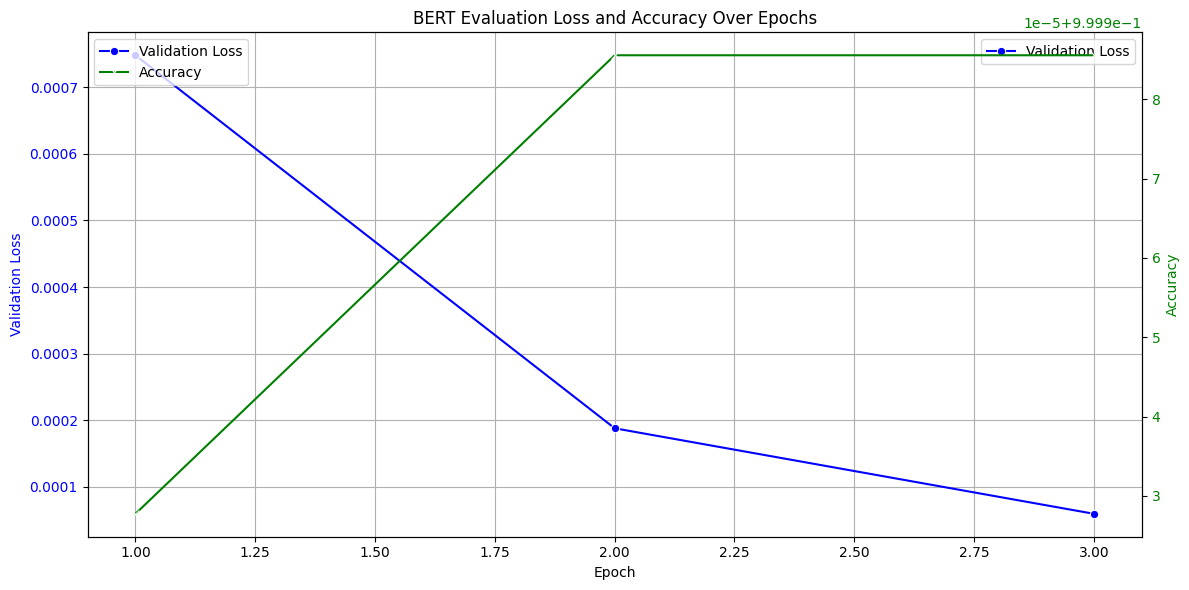

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a primary axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Validation Loss on the primary y-axis
sns.lineplot(x='Epoch', y='Validation Loss', data=bert_metrics_df, marker='o', ax=ax1, color='blue', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Validation Loss', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot Accuracy on the secondary y-axis
sns.lineplot(x='Epoch', y='Accuracy', data=bert_metrics_df, marker='x', ax=ax2, color='green', label='Accuracy')
ax2.set_ylabel('Accuracy', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Set title and grid
plt.title('BERT Evaluation Loss and Accuracy Over Epochs')
ax1.grid(True)

# Add legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='best')

plt.tight_layout()
plt.show()


/tmp/ipykernel_3016/636571139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=balanced_df, x='Rating', palette='viridis')


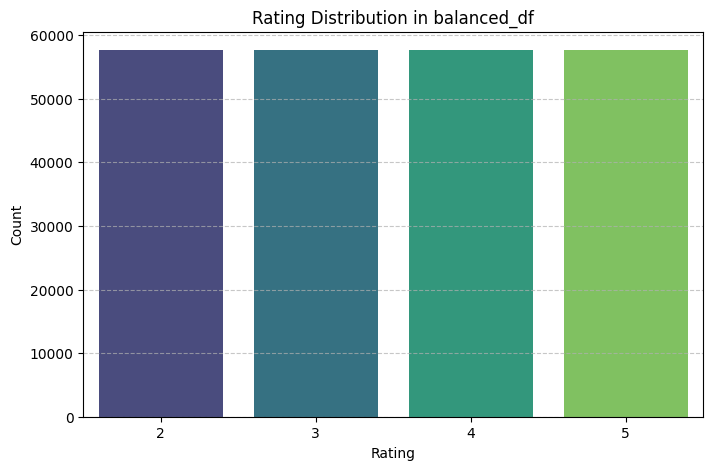

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=balanced_df, x='Rating', palette='viridis')
plt.title("Rating Distribution in balanced_df")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

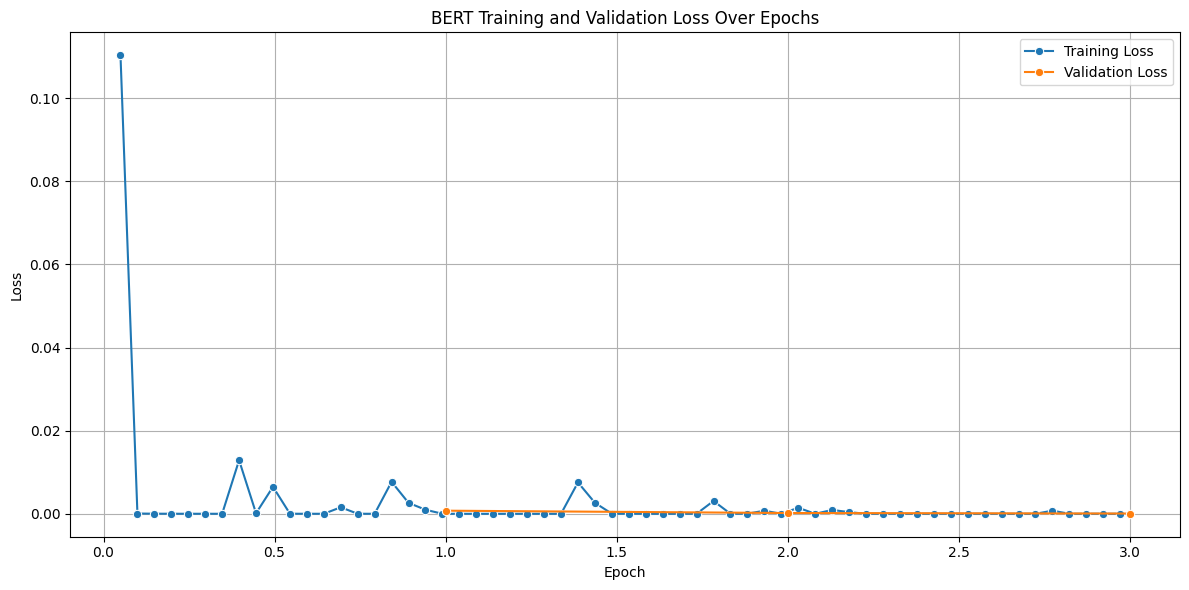

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract training and validation loss from trainer.state.log_history
bert_loss_metrics = []
for log_entry in trainer.state.log_history:
    if 'loss' in log_entry and 'eval_loss' not in log_entry: # Training loss entries
        bert_loss_metrics.append({
            'Epoch': log_entry['epoch'],
            'Loss Type': 'Training Loss',
            'Loss': log_entry['loss']
        })
    elif 'eval_loss' in log_entry: # Validation loss entries
        bert_loss_metrics.append({
            'Epoch': log_entry['epoch'],
            'Loss Type': 'Validation Loss',
            'Loss': log_entry['eval_loss']
        })

bert_loss_df = pd.DataFrame(bert_loss_metrics)

# Plotting BERT Training and Validation Loss
plt.figure(figsize=(12, 6))
sns.lineplot(x='Epoch', y='Loss', hue='Loss Type', data=bert_loss_df, marker='o')
plt.title('BERT Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

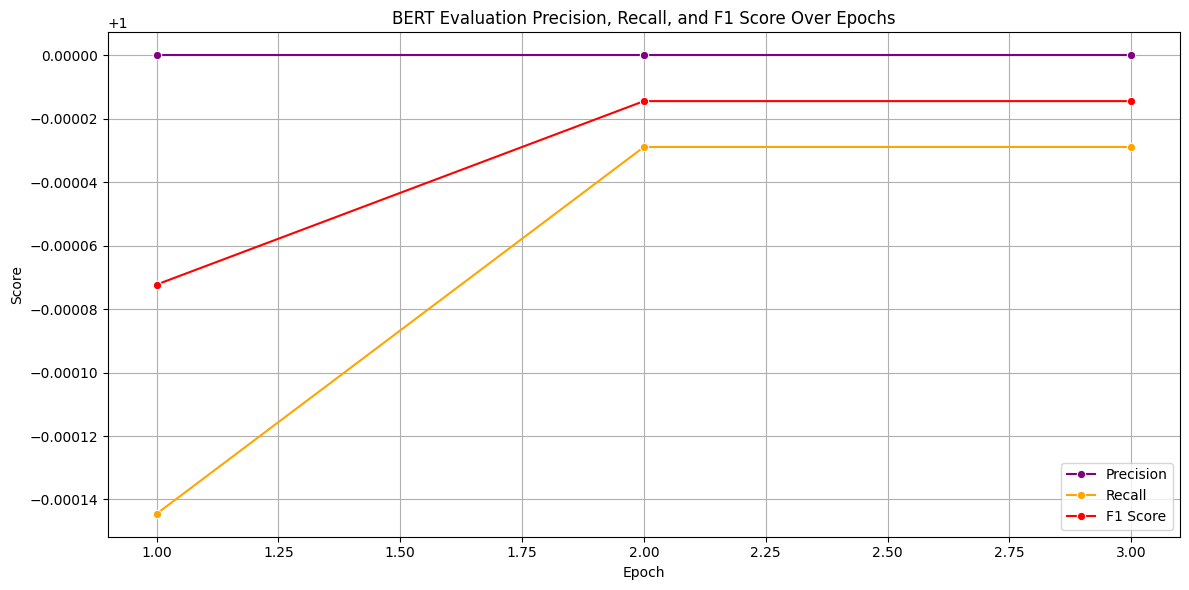

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Epoch', y='Precision', data=bert_metrics_df, marker='o', label='Precision', color='purple')
sns.lineplot(x='Epoch', y='Recall', data=bert_metrics_df, marker='o', label='Recall', color='orange')
sns.lineplot(x='Epoch', y='F1', data=bert_metrics_df, marker='o', label='F1 Score', color='red')

plt.title('BERT Evaluation Precision, Recall, and F1 Score Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


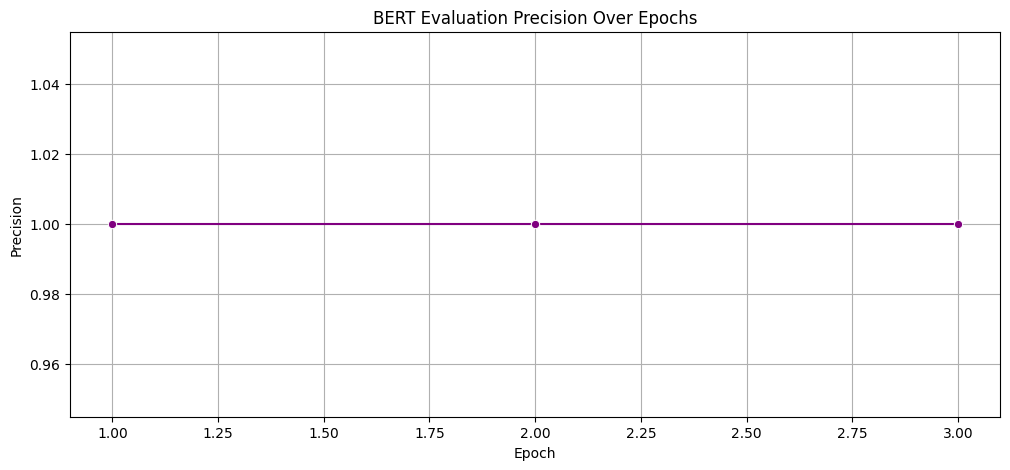

In [ ]:
# Plotting BERT Evaluation Precision
plt.figure(figsize=(12, 5))
sns.lineplot(x='Epoch', y='Precision', data=bert_metrics_df, marker='o', color='purple')
plt.title('BERT Evaluation Precision Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

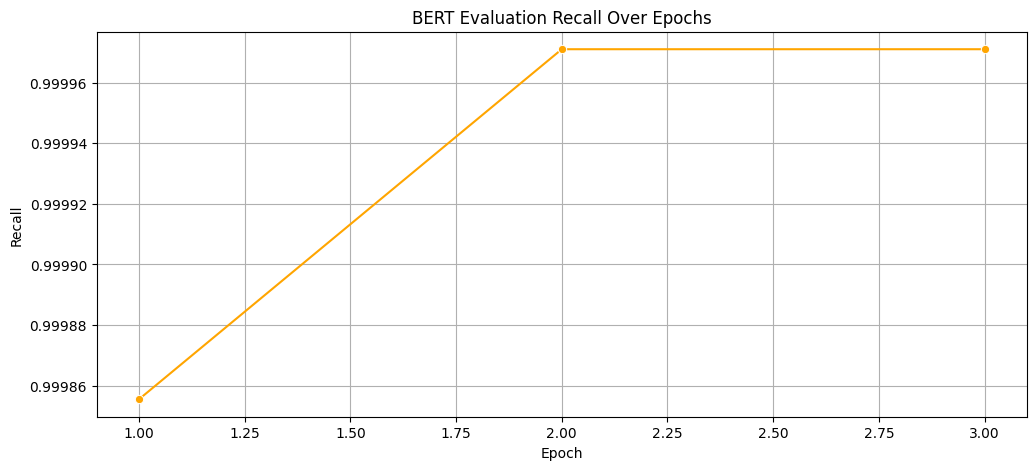

In [ ]:
# Plotting BERT Evaluation Recall
plt.figure(figsize=(12, 5))
sns.lineplot(x='Epoch', y='Recall', data=bert_metrics_df, marker='o', color='orange')
plt.title('BERT Evaluation Recall Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.grid(True)
plt.show()

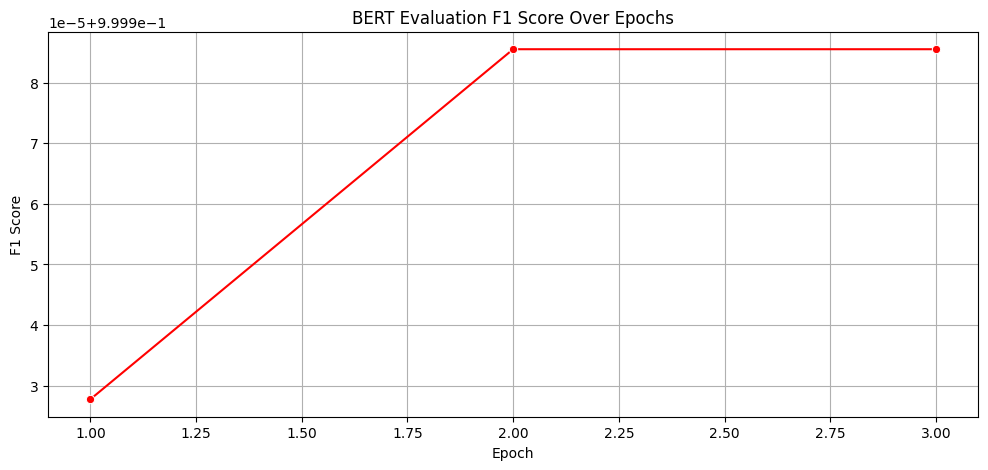

In [ ]:
# Plotting BERT Evaluation F1 Score
plt.figure(figsize=(12, 5))
sns.lineplot(x='Epoch', y='F1', data=bert_metrics_df, marker='o', color='red')
plt.title('BERT Evaluation F1 Score Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.grid(True)
plt.show()

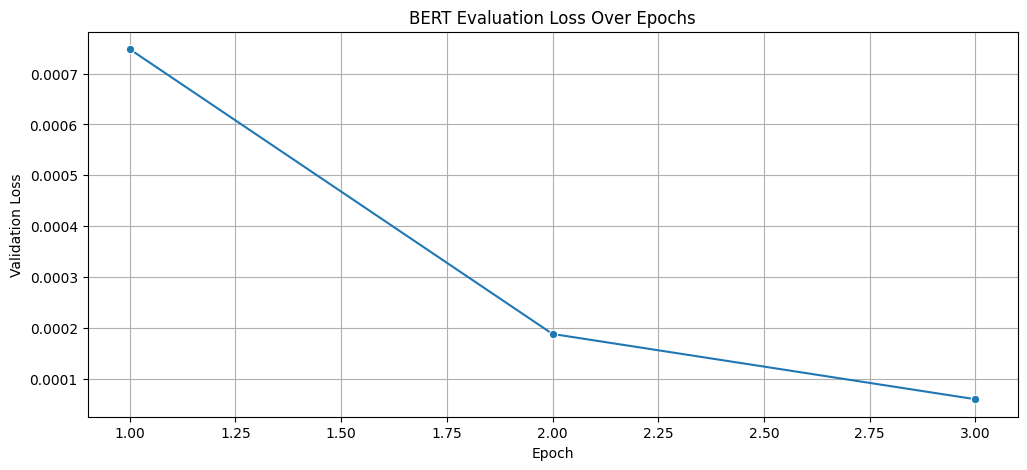

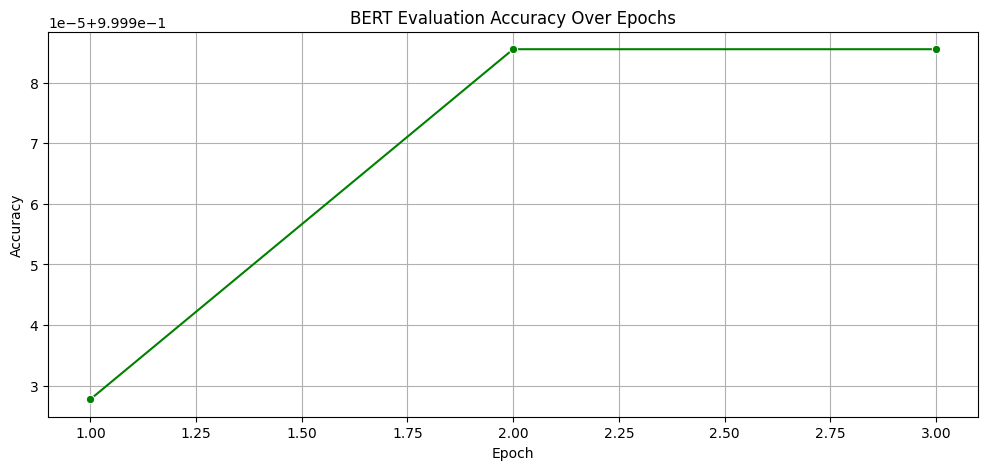

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract evaluation metrics for BERT from trainer.state.log_history
bert_eval_metrics = []
for log_entry in trainer.state.log_history:
    if 'eval_loss' in log_entry:
        bert_eval_metrics.append({
            'Epoch': log_entry['epoch'],
            'Validation Loss': log_entry['eval_loss'],
            'Accuracy': log_entry['eval_accuracy'],
            'Precision': log_entry['eval_precision'],
            'Recall': log_entry['eval_recall'],
            'F1': log_entry['eval_f1']
        })

bert_metrics_df = pd.DataFrame(bert_eval_metrics)

# Plotting BERT Evaluation Loss
plt.figure(figsize=(12, 5))
sns.lineplot(x='Epoch', y='Validation Loss', data=bert_metrics_df, marker='o')
plt.title('BERT Evaluation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.grid(True)
plt.show()

# Plotting BERT Evaluation Accuracy
plt.figure(figsize=(12, 5))
sns.lineplot(x='Epoch', y='Accuracy', data=bert_metrics_df, marker='o', color='green')
plt.title('BERT Evaluation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


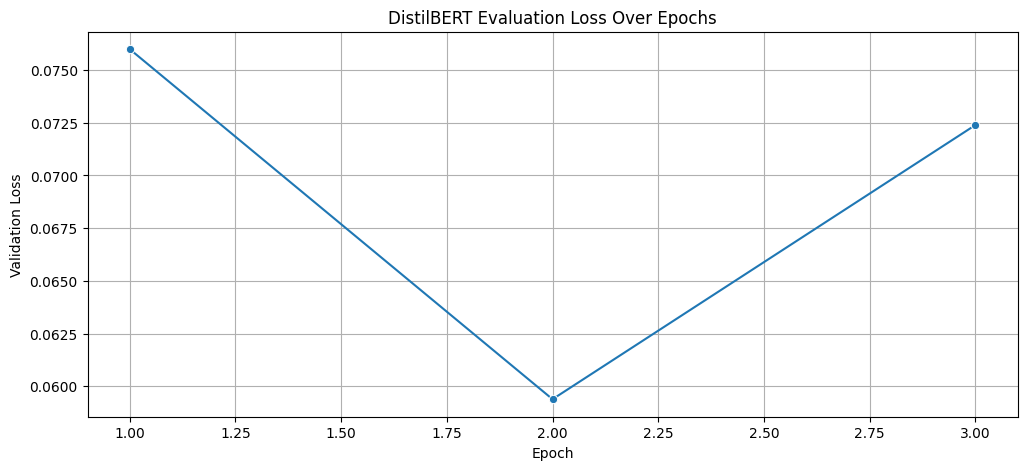

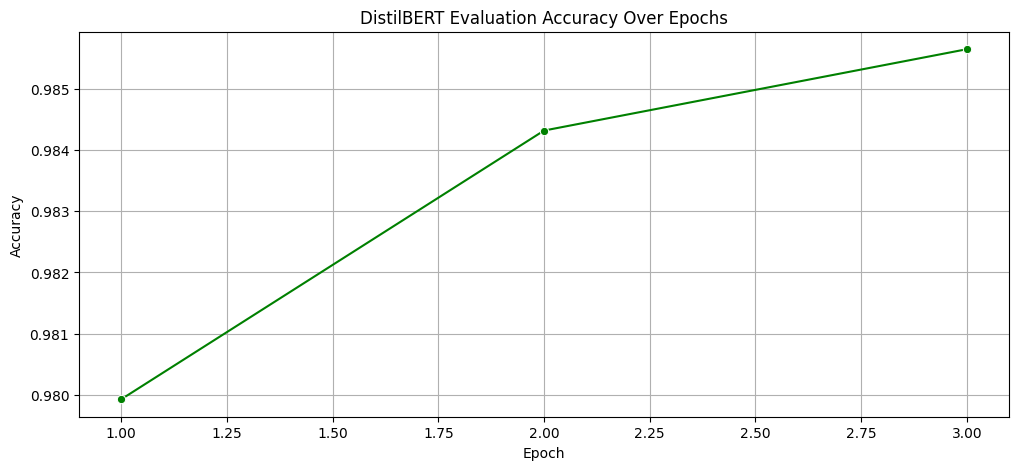

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract data from the text cell (simulating parsing the text output)
metrics_data = {
    'Epoch': [1, 2, 3],
    'Training Loss': [0.0901, 0.0450, 0.0150],
    'Validation Loss': [0.075984, 0.059391, 0.072386],
    'Accuracy': [0.979927, 0.984320, 0.985650],
    'Precision': [0.979193, 0.990918, 0.987835],
    'Recall': [0.980693, 0.977600, 0.983409],
    'F1': [0.979942, 0.984214, 0.985617]
}

metrics_df = pd.DataFrame(metrics_data)

# Plotting Evaluation Loss
plt.figure(figsize=(12, 5))
sns.lineplot(x='Epoch', y='Validation Loss', data=metrics_df, marker='o')
plt.title('DistilBERT Evaluation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.grid(True)
plt.show()

# Plotting Evaluation Accuracy
plt.figure(figsize=(12, 5))
sns.lineplot(x='Epoch', y='Accuracy', data=metrics_df, marker='o', color='green')
plt.title('DistilBERT Evaluation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


### ROBERTA Model

In [ ]:
# Load RoBERTa model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

# Tokenize the reviews
inputs = tokenizer(list(balanced_df['Review']), padding=True, truncation=True, return_tensors="pt", max_length=128)
labels = torch.tensor(balanced_df['Popularity'].values)

# Train-test split
train_idx, test_idx = train_test_split(range(len(balanced_df)), test_size=0.3, random_state=42, stratify=balanced_df['Popularity'])
train_inputs = {key: inputs[key][train_idx] for key in inputs}
train_labels = labels[train_idx]
test_inputs = {key: inputs[key][test_idx] for key in inputs}
test_labels = labels[test_idx]

# Dataset Class
class TourismDataset(torch.utils.data.Dataset):
    def __init__(self, inputs, labels):
        self.inputs = inputs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: self.inputs[key][idx] for key in self.inputs}
        item['labels'] = self.labels[idx]
        return item

train_dataset = TourismDataset(train_inputs, train_labels)
test_dataset = TourismDataset(test_inputs, test_labels)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    logging_dir='./logs',
    report_to="none"
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=lambda p: {
        'accuracy': accuracy_score(p.label_ids, np.argmax(p.predictions, axis=1)),
        'precision': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[0],
        'recall': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[1],
        'f1': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[2],
    }
)

trainer.train()
evaluation_results = trainer.evaluate()
print("Evaluation Results for RoBERTa:", evaluation_results)




tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.457800,0.363393,0.873737,0.823093,0.952107,0.882912
2,0.396400,0.387118,0.870052,0.876028,0.862102,0.869009
3,0.389400,0.385567,0.864055,0.816748,0.938725,0.873499


Evaluation Results for RoBERTa: {'eval_loss': 0.385566771030426, 'eval_accuracy': 0.8640548000635866, 'eval_precision': 0.8167483968313843, 'eval_recall': 0.9387247817792936, 'eval_f1': 0.8734989174723989, 'eval_runtime': 403.0605, 'eval_samples_per_second': 171.679, 'eval_steps_per_second': 2.684, 'epoch': 3.0}


In [ ]:
# Load ALBERT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")
model = AutoModelForSequenceClassification.from_pretrained("albert-base-v2", num_labels=2)

# Tokenize the reviews
inputs = tokenizer(list(balanced_df['Review']), padding=True, truncation=True, return_tensors="pt", max_length=128)
labels = torch.tensor(balanced_df['Popularity'].values)

# Train-test split
train_idx, test_idx = train_test_split(range(len(balanced_df)), test_size=0.3, random_state=42, stratify=balanced_df['Popularity'])
train_inputs = {key: inputs[key][train_idx] for key in inputs}
train_labels = labels[train_idx]
test_inputs = {key: inputs[key][test_idx] for key in inputs}
test_labels = labels[test_idx]

# Dataset Class
class TourismDataset(torch.utils.data.Dataset):
    def __init__(self, inputs, labels):
        self.inputs = inputs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: self.inputs[key][idx] for key in self.inputs}
        item['labels'] = self.labels[idx]
        return item

train_dataset = TourismDataset(train_inputs, train_labels)
test_dataset = TourismDataset(test_inputs, test_labels)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    logging_dir='./logs',
    report_to="none"
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=lambda p: {
        'accuracy': accuracy_score(p.label_ids, np.argmax(p.predictions, axis=1)),
        'precision': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[0],
        'recall': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[1],
        'f1': precision_recall_fscore_support(p.label_ids, np.argmax(p.predictions, axis=1), average='binary')[2],
    }
)


trainer.train()
evaluation_results = trainer.evaluate()
print("Evaluation Results for ALBERT:", evaluation_results)




tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.162000,0.139515,0.953582,0.945191,0.963004,0.954014
2,0.104700,0.104774,0.971025,0.983791,0.957830,0.970637
3,0.052200,0.095230,0.976646,0.981433,0.971675,0.976529


Evaluation Results for ALBERT: {'eval_loss': 0.0952301174402237, 'eval_accuracy': 0.9766463864040349, 'eval_precision': 0.9814328253634612, 'eval_recall': 0.9716746632753338, 'eval_f1': 0.9765293673386394, 'eval_runtime': 487.736, 'eval_samples_per_second': 141.874, 'eval_steps_per_second': 2.218, 'epoch': 3.0}


Hierarchical Attention Mechanism (HAM) with DistilBERT

In [ ]:
from transformers import AutoTokenizer, DistilBertModel, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# Step 6: Initialize tokenizer and custom model with hierarchical attention
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

class HierarchicalDistilBERT(nn.Module):
    def __init__(self, num_labels=2):
        super(HierarchicalDistilBERT, self).__init__()
        self.distilbert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.attention_layer = nn.MultiheadAttention(embed_dim=768, num_heads=8)
        self.classifier = nn.Linear(768, num_labels)
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask, labels=None):
        distilbert_output = self.distilbert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        doc_rep, _ = self.attention_layer(distilbert_output, distilbert_output, distilbert_output)
        doc_rep = doc_rep.mean(dim=1)
        logits = self.classifier(doc_rep)

        # Compute loss if labels are provided
        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels)

        # Return logits and optionally loss for compatibility with Trainer
        return {"loss": loss, "logits": logits}

model = HierarchicalDistilBERT(num_labels=2)

# Tokenize and prepare inputs
inputs = tokenizer(list(balanced_df['Review']), padding=True, truncation=True, return_tensors="pt", max_length=128)
labels = torch.tensor(balanced_df['Popularity'].values)

# Train-test split
train_idx, test_idx = train_test_split(range(len(balanced_df)), test_size=0.3, random_state=42, stratify=balanced_df['Popularity'])
train_inputs = {key: inputs[key][train_idx] for key in inputs}
train_labels = labels[train_idx]
test_inputs = {key: inputs[key][test_idx] for key in inputs}
test_labels = labels[test_idx]

# Custom Dataset Class
class TourismDataset(torch.utils.data.Dataset):
    def __init__(self, inputs, labels):
        self.inputs = inputs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: self.inputs[key][idx] for key in self.inputs}
        item['labels'] = self.labels[idx]
        return item

train_dataset = TourismDataset(train_inputs, train_labels)
test_dataset = TourismDataset(test_inputs, test_labels)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    logging_dir='./logs',
    report_to="none"
)

# Trainer
def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, predictions, average='binary')
    acc = accuracy_score(p.label_ids, predictions)
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Step 8: Train and evaluate the model
trainer.train()
evaluation_results = trainer.evaluate()
print("Evaluation Results:", evaluation_results)




/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.092700,0.080871,0.979118,0.981301,0.976848,0.979070
2,0.049700,0.076892,0.983684,0.988385,0.978872,0.983605
3,0.019500,0.078236,0.985736,0.988376,0.983034,0.985698


Evaluation Results: {'eval_loss': 0.07823643088340759, 'eval_accuracy': 0.9857363758544445, 'eval_precision': 0.9883758100607364, 'eval_recall': 0.9830337013700214, 'eval_f1': 0.9856975177150806, 'eval_runtime': 261.7671, 'eval_samples_per_second': 264.346, 'eval_steps_per_second': 4.133, 'epoch': 3.0}


 Contrastive Learning for Text Similarity in Classification

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
import torch.nn.functional as F
import numpy as np

# Step 6: Initialize tokenizer and model for contrastive learning
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Contrastive similarity function
def contrastive_similarity_loss(embeddings, labels, margin=0.5):
    positive_mask = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
    # Calculate cosine similarity along the correct dimension (dim=1)
    distances = 1 - F.cosine_similarity(embeddings.unsqueeze(0), embeddings.unsqueeze(1), dim=1)
    losses = positive_mask * distances + (1 - positive_mask) * F.relu(margin - distances)
    return losses.mean()

# Tokenize and prepare inputs
inputs = tokenizer(list(balanced_df['Review']), padding=True, truncation=True, return_tensors="pt", max_length=128)
labels = torch.tensor(balanced_df['Popularity'].values)

# Train-test split
train_idx, test_idx = train_test_split(range(len(balanced_df)), test_size=0.3, random_state=42, stratify=balanced_df['Popularity'])
train_inputs = {key: inputs[key][train_idx] for key in inputs}
train_labels = labels[train_idx]
test_inputs = {key: inputs[key][test_idx] for key in inputs}
test_labels = labels[test_idx]

# Custom Dataset Class
class TourismDataset(torch.utils.data.Dataset):
    def __init__(self, inputs, labels):
        self.inputs = inputs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: self.inputs[key][idx] for key in self.inputs}
        item['labels'] = self.labels[idx]
        return item

train_dataset = TourismDataset(train_inputs, train_labels)
test_dataset = TourismDataset(test_inputs, test_labels)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    logging_dir='./logs',
    report_to="none"
)

# Metric computation
def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, predictions, average='binary')
    acc = accuracy_score(p.label_ids, predictions)
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

# Custom Trainer for contrastive learning
class ContrastiveTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None): # Add num_items_in_batch argument
        # Extract labels and inputs, handle additional arguments if needed
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        embeddings = outputs.logits.mean(dim=1)  # Pooling for contrastive loss
        loss = contrastive_similarity_loss(embeddings, labels)
        return (loss, outputs) if return_outputs else loss

# Initialize Trainer with contrastive loss
trainer = ContrastiveTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Step 8: Train and evaluate the model
trainer.train()
evaluation_results = trainer.evaluate()
print("Evaluation Results:", evaluation_results)




Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.234400,0.246027,0.499993,0.499993,1.000000,0.666660
2,0.234500,0.246027,0.500007,0.000000,0.000000,0.000000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.234400,0.246027,0.499993,0.499993,1.000000,0.666660
2,0.234500,0.246027,0.500007,0.000000,0.000000,0.000000
3,0.232500,0.246027,0.500007,0.000000,0.000000,0.000000


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Evaluation Results: {'eval_loss': 0.2460273653268814, 'eval_accuracy': 0.5000072257467809, 'eval_precision': 0.0, 'eval_recall': 0.0, 'eval_f1': 0.0, 'eval_runtime': 249.1843, 'eval_samples_per_second': 277.694, 'eval_steps_per_second': 4.342, 'epoch': 3.0}


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Dynamic Transformer Architectures with Curriculum Learning

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
import numpy as np

# Step 6: Initialize tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Curriculum learning setup: progressively increase max_length
max_lengths = [64, 96, 128]
labels = torch.tensor(balanced_df['Popularity'].values)

for max_length in max_lengths:
    # Tokenize and prepare inputs with gradually increasing max_length
    inputs = tokenizer(list(balanced_df['Review']), padding=True, truncation=True, return_tensors="pt", max_length=max_length)

    # Train-test split
    train_idx, test_idx = train_test_split(range(len(balanced_df)), test_size=0.3, random_state=42, stratify=balanced_df['Popularity'])
    train_inputs = {key: inputs[key][train_idx] for key in inputs}
    train_labels = labels[train_idx]
    test_inputs = {key: inputs[key][test_idx] for key in inputs}
    test_labels = labels[test_idx]

    train_dataset = TourismDataset(train_inputs, train_labels)
    test_dataset = TourismDataset(test_inputs, test_labels)

    # Instantiate and train model for each curriculum phase
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )

    print(f"Training with max_length={max_length}")
    trainer.train()

# Final evaluation after curriculum training
evaluation_results = trainer.evaluate()
print("Final Evaluation Results:", evaluation_results)




Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training with max_length=64


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.082900,0.085165,0.973091,0.961434,0.985722,0.973427
2,0.048600,0.064090,0.984826,0.988981,0.980577,0.984761
3,0.013000,0.074885,0.986170,0.987282,0.985028,0.986154


Training with max_length=96


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.040200,0.093655,0.980649,0.982308,0.978929,0.980616
2,0.018100,0.098692,0.983728,0.988015,0.979334,0.983656
3,0.004500,0.110168,0.983699,0.985269,0.982080,0.983672


Training with max_length=128


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.026800,0.114941,0.978771,0.981232,0.976212,0.978716


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.026800,0.114941,0.978771,0.981232,0.976212,0.978716
2,0.011600,0.124217,0.980953,0.988751,0.972975,0.980799
3,0.003200,0.127374,0.982803,0.987281,0.978207,0.982723


Final Evaluation Results: {'eval_loss': 0.12737412750720978, 'eval_accuracy': 0.982802722661387, 'eval_precision': 0.9872812135355893, 'eval_recall': 0.9782068327648997, 'eval_f1': 0.9827230755829147, 'eval_runtime': 240.7218, 'eval_samples_per_second': 287.456, 'eval_steps_per_second': 4.495, 'epoch': 3.0}
